训练完成！测试准确率: 84.44%


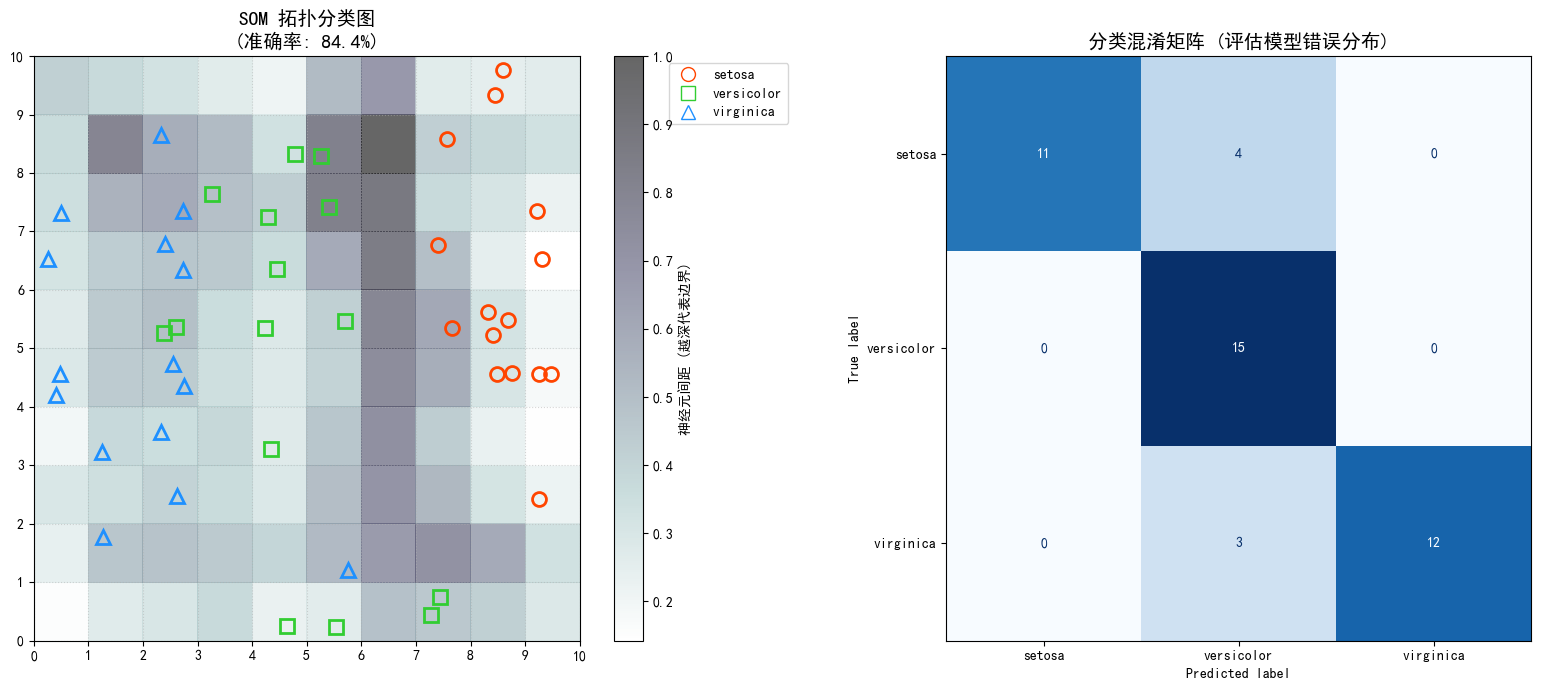

In [ ]:
# coding=utf-8
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from minisom import MiniSom
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt
import math

# 设置支持中文显示（如果报错可注释掉）
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

def classify(som, data, winmap):
    # 找到全图出现频率最高的类作为默认类（防御性编程）
    from collections import Counter
    all_labels = []
    for _, counter in winmap.items():
        all_labels.extend(list(counter.elements()))
    default_class = Counter(all_labels).most_common()[0][0] if all_labels else 0
    
    result = []
    for d in data:
        win_position = som.winner(d)
        if win_position in winmap:
            result.append(winmap[win_position].most_common()[0][0])
        else:
            result.append(default_class)
    return result

if __name__ == '__main__':
    # 1. 加载数据
    iris = load_iris()
    X, y = iris.data, iris.target
    target_names = iris.target_names
    
    # 2. 预处理
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X_train, X_test, Y_train, Y_test = train_test_split(
        X_scaled, y, test_size=0.3, random_state=42, stratify=y
    )
    
    # 3. 训练 SOM (增加神经元数量让地图更精细)
    size = 10 
    som = MiniSom(size, size, X_train.shape[1], sigma=1.2, learning_rate=0.5, 
                  neighborhood_function='gaussian', random_seed=42)
    som.pca_weights_init(X_train)
    som.train_batch(X_train, 1000, verbose=False)
    
    # 4. 预测与评估
    winmap = som.labels_map(X_train, Y_train)
    y_pred = classify(som, X_test, winmap)
    accuracy = np.mean(np.array(y_pred) == Y_test)

    # ================== 优化可视化部分 ==================
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

    # --- 左图：SOM 距离矩阵与分类分布图 ---
    # 背景是 U-Matrix (显示神经元之间的距离，浅色表示距离近，深色表示边界)
    u_matrix = som.distance_map().T
    im = ax1.pcolor(u_matrix, cmap='bone_r', alpha=0.6) 
    fig.colorbar(im, ax=ax1, label='神经元间距 (越深代表边界)')

    # 在地图上标记测试集样本
    markers = ['o', 's', '^']
    colors = ['#FF4500', '#32CD32', '#1E90FF'] # 橙红, 绿, 蓝
    
    for i, (d, label) in enumerate(zip(X_test, Y_test)):
        w = som.winner(d)
        # 加入微小的随机偏移(Jitter)，防止多个点重叠在一个格子里看不清
        ax1.plot(w[0] + 0.5 + np.random.uniform(-0.3, 0.3), 
                 w[1] + 0.5 + np.random.uniform(-0.3, 0.3), 
                 markers[label], markerfacecolor='None', 
                 markeredgecolor=colors[label], markersize=10, markeredgewidth=2)

    ax1.set_title(f'SOM 拓扑分类图\n(准确率: {accuracy*100:.1f}%)', fontsize=14)
    ax1.set_xticks(range(size + 1))
    ax1.set_yticks(range(size + 1))
    ax1.grid(True, linestyle=':', alpha=0.5)

    # 手动添加左图图例
    from matplotlib.lines import Line2D
    legend_elements = [Line2D([0], [0], marker=markers[i], color='w', label=target_names[i],
                              markeredgecolor=colors[i], markersize=10) for i in range(3)]
    ax1.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.15, 1))

    # --- 右图：混淆矩阵 ---
    cm = confusion_matrix(Y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
    disp.plot(ax=ax2, cmap='Blues', colorbar=False)
    ax2.set_title('分类混淆矩阵 (评估模型错误分布)', fontsize=14)

    plt.tight_layout()
    print(f"训练完成！测试准确率: {accuracy*100:.2f}%")
    plt.show()